# Introduction
This notebook serves as a comprehensive learning module that combines hands-on coding, conceptual insights, and structured student tasks. The flow mirrors a real deep learning workflow—from loading data and building models to understanding optimization, regularization, and model behavior.

The notebook is organized into **three major sections**, each designed to progressively deepen the learner's understanding of neural networks and training dynamics.


## Section 1 — Practical Part #1: Building & Training a Neural Network

### **What this section covers:**
- Loading and preprocessing the MNIST dataset
- Flattening image data for fully connected networks
- Building a neural network with:
  - Input layer (Flatten)
  - Hidden Dense layer (ReLU activation)
  - Output layer (Softmax activation)
- Compiling the model using the **Adam optimizer**
- Training the model and monitoring training/validation loss
- Predicting and visualizing test samples

### **Learning Outcome:**
Students gain a practical understanding of how forward and backward passes operate within a simple neural network.

[mnist dataset Link](https://datasets.activeloop.ai/docs/ml/datasets/mnist/)
---


In [ ]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
x_train ,  x_test = x_train / 255.0 , x_test/255.0

In [ ]:
len(x_train)

60000

In [ ]:
x_train[5].shape

(28, 28)

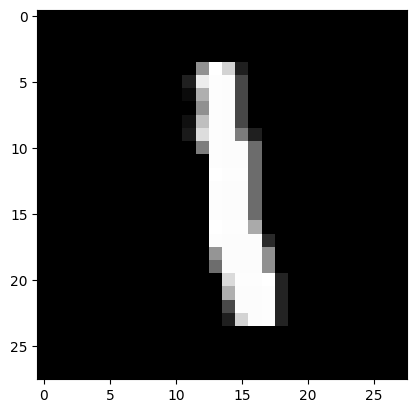

In [ ]:
plt.imshow(x_train[6], cmap = "gray")

In [ ]:
model= keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)), # input layer > 2D to 1D
  keras.layers.Dense(128, activation="relu"), # hidden layer 1
  keras.layers.Dense(10, activation= "softmax" ) # output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# adam Adaptive Moment Estimation (RMSporb+ Momenmtum) > Optimizer
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


train test

train validation test

In [ ]:
history = model.fit(x_train,y_train ,epochs = 5 ,validation_data=(x_test, y_test) ) # train ,  test

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8730 - loss: 0.4415 - val_accuracy: 0.9575 - val_loss: 0.1406
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9643 - loss: 0.1259 - val_accuracy: 0.9676 - val_loss: 0.1057
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9763 - loss: 0.0795 - val_accuracy: 0.9734 - val_loss: 0.0903
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0556 - val_accuracy: 0.9769 - val_loss: 0.0771
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9872 - loss: 0.0443 - val_accuracy: 0.9766 - val_loss: 0.0753


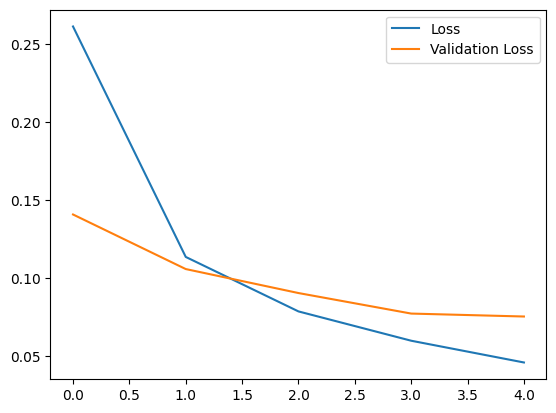

In [ ]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
prediction = model.predict(x_test[14].reshape(1, 28, 28))  # 10 pred
print("Prediction:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction: 1


In [ ]:
print(prediction)

[[1.4388617e-08 9.9957579e-01 1.9863926e-06 2.5403249e-04 8.9174205e-07
  2.6198774e-07 8.4477006e-07 5.1636389e-06 1.5492026e-04 6.1603419e-06]]


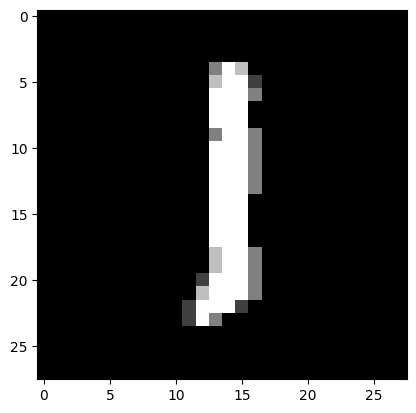

In [ ]:
plt.imshow(x_test[14], cmap = "gray")

## Section 2 — Practical Part #2: Data Splitting, Regularization & Early Stopping

### **Key Concepts Introduced:**
#### **1. Proper Dataset Splitting**
**General Idea**

- **Training set**: The model learns from this data.  
- **Validation set**: Used during training to tune hyperparameters and prevent overfitting.  
- **Test set**: Kept aside until the very end to measure the model’s *true performance* on completely unseen data.  

**Important Note**:  
If you use `x_test` directly as your validation set, this is a mistake.  
Why? Because you will end up tuning your model on the same data that you later claim to be your “unseen test set,” which makes the final evaluation biased.  

The correct workflow:
1. Split the dataset into **train + test** (e.g., 80% train, 20% test).  
2. From the **train** portion, further split into **train + validation** (e.g., 70% train, 10% validation, 20% test).  
3. Use the **validation set** only for model tuning.  
4. Use the **test set** once at the end for the final unbiased performance check.

#### **2. Regularization Techniques**
- Adding **Dropout** layers to reduce overfitting
- Using **EarlyStopping** to detect convergence and stop training

#### **3. Improved Model Pipeline**
- Training over more epochs
- Monitoring training vs. validation performance
- Evaluating on the final test set
- Predicting and analyzing results

### **Learning Outcome:**
Students understand how model generalization is improved using splitting, dropout, and early stopping.

---


In [4]:
# import tensorflow as tf
# from tensorflow import keras
# import numpy as np
# import matplotlib.pyplot as plt

# 1) Load Dataset
# (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values (0-255 -> 0-1)
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0

# 2) Split Validation Set from Training Set
# Reserve last 5000 samples for validation
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_tr = x_train[:-5000]
y_tr = y_train[:-5000]
print("Train shape:", x_tr.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (55000, 28, 28)
Validation shape: (5000, 28, 28)
Test shape: (10000, 28, 28)


In [ ]:

# 3) Build Model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),   # prevent overfitting
    keras.layers.Dense(10, activation="softmax")
])

# 4) Compile Model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


In [ ]:

# 5) Train with Validation Set
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

history = model.fit(
    x_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)


Epoch 1/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9376 - loss: 0.2170 - val_accuracy: 0.9750 - val_loss: 0.0959
Epoch 2/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9634 - loss: 0.1240 - val_accuracy: 0.9783 - val_loss: 0.0808
Epoch 3/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.0895 - val_accuracy: 0.9797 - val_loss: 0.0764
Epoch 4/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9797 - loss: 0.0669 - val_accuracy: 0.9790 - val_loss: 0.0773
Epoch 5/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0560 - val_accuracy: 0.9800 - val_loss: 0.0786
Epoch 6/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9843 - loss: 0.0491 - val_accuracy: 0.9833 - val_loss: 0.0771


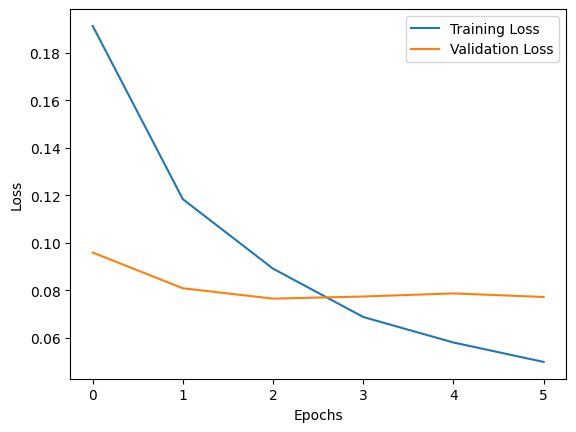

In [ ]:

# 6) Plot Training vs Validation Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# 7) Evaluate on Test Set
print("Final evaluation on test data:")
model.evaluate(x_test, y_test)

Final evaluation on test data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.0826


[0.06802161037921906, 0.9793999791145325]

In [ ]:
# 8) Predict Example
sample = x_test[15].reshape(1, 28, 28)
pred = model.predict(sample)
print("Predicted Label:", np.argmax(pred))
print("True Label:", y_test[15])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Label: 5
True Label: 5


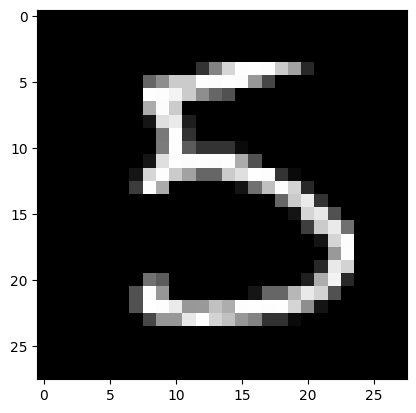

In [ ]:
plt.imshow(x_test[15], cmap="gray")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label: 7
True Label: 7


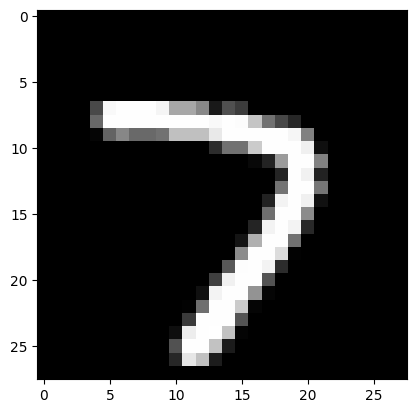

In [ ]:
# 8) Predict Example
sample = x_test[17].reshape(1, 28, 28)
pred = model.predict(sample)
print("Predicted Label:", np.argmax(pred))
print("True Label:", y_test[17])
plt.imshow(x_test[17], cmap="gray")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label: 6
True Label: 6


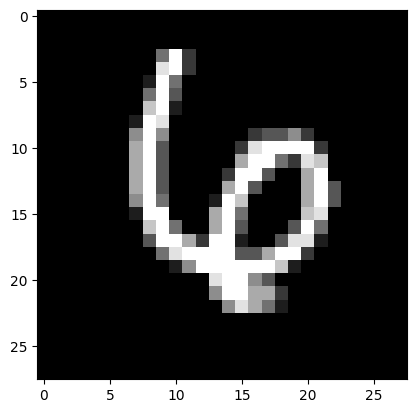

In [ ]:
# 8) Predict Example
sample = x_test[22].reshape(1, 28, 28)
pred = model.predict(sample)
print("Predicted Label:", np.argmax(pred))
print("True Label:", y_test[22])
plt.imshow(x_test[22], cmap="gray")
plt.show()

**Task 1**

How the forward pass transforms inputs through layers?

The forward pass is the process where an input single image goes through all the layers of the network until it produces an output prediction,the input layer takes single 28x28 grayscale image and then it is flattened into a one-dimensional vector of 28x28=784 pixels values. After this, input goes to the hidden layer of 128 neurons and each neuron does a transformation by Z = W dot X + b and those transformations leads to learn to detect simple edges or corners. The output of the first layer becomes the input for the next layer(hidden), and the process repeats. Each subsequent layer builds the features extracted by the previous layer, developing increasing complex features forming loops, lines, and curves until the output layer which results in logits with probabilities for each value from 0 to 9.

**The role of activation functions (ReLU, Softmax)**

Activation functions are critical because they introduce non-linearity into the NN models, allowing the network to learn complex relationships and features.

**Rectified Linear Unit (ReLU)** is typically used in hidden layer neurons and it defines as Z=max(0,X), it sets all negative inputs to zero. This makes the resulting output sparse and computationally efficient, helping the model to focus on the positive, important features.

**Softmax** is used in the final output layer. It takes the raw scores (logits) from the final layer and turn them into a probability distribution over the N classes (where N=10 for digits 0-9). The output is a vector of 10 values, where each value is between 0 and 1, and all 10 values sum to 1.

**How the optimizer (Adam) may have shaped weight updates during training?**

The optimizer is the algorithm used during the back propagation (training) to adjust the model's weights and biases (the W and B parameters) to minimize the prediction error (loss). Adam (short for Adaptive Moment Estimation) doesn't use a single, fixed learning rate. Instead, it calculates a learning rate for each weight in the model.
Parameters (weights) that need to be changed drastically are adjusted with a larger step, while other parameters are adjusted with a smaller step. This leads to faster convergence and better performance than non-adaptive optimizers.
Adam uses a concept similar to Momentum, which tracks the past weight updates, this helps the optimizer gain speed in the direction of the minimum loss and overshoot local minima in the loss curve.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Label: 2


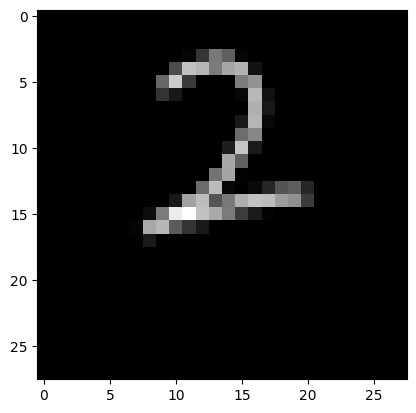

In [ ]:
# task 2
from PIL import Image
img = Image.open('/content/2.jpg')
img = img.convert('L').resize((28, 28))
img_array = np.array(img)
img_array = img_array.reshape(1, 28, 28)
img_array = img_array.astype("float32") / 255.0
pred = model.predict(img_array)
print("Predicted Label:", np.argmax(pred))
plt.imshow(img_array[0], cmap="gray")
plt.show()

In [ ]:
print(pred)

[[6.6100809e-05 1.5470741e-02 6.7781764e-01 1.0275350e-01 1.8503295e-01
  3.4060600e-04 7.2154135e-04 1.0606703e-02 7.1460875e-03 4.4197845e-05]]


Task 2 — Custom Image Generalization Test


Did the model correctly classify the digit? YES

How does this relate to representation learning in neural networks?

Representation learning is the network's ability to automatically discover and extract features from raw data. The correct prediction on an unseen photo confirms the model successfully learned the generalized representations of the digits, not just memorized the training examples.

Epoch 1/5
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8630 - loss: 0.4675 - val_accuracy: 0.9707 - val_loss: 0.1107
Epoch 2/5
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9582 - loss: 0.1381 - val_accuracy: 0.9773 - val_loss: 0.0802
Epoch 3/5
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9702 - loss: 0.0961 - val_accuracy: 0.9793 - val_loss: 0.0707
Epoch 4/5
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9767 - loss: 0.0745 - val_accuracy: 0.9833 - val_loss: 0.0677
Epoch 5/5
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0605 - val_accuracy: 0.9827 - val_loss: 0.0640


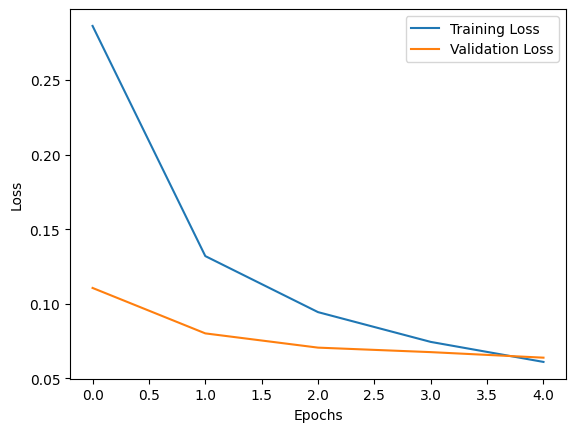

*****************************************************************************


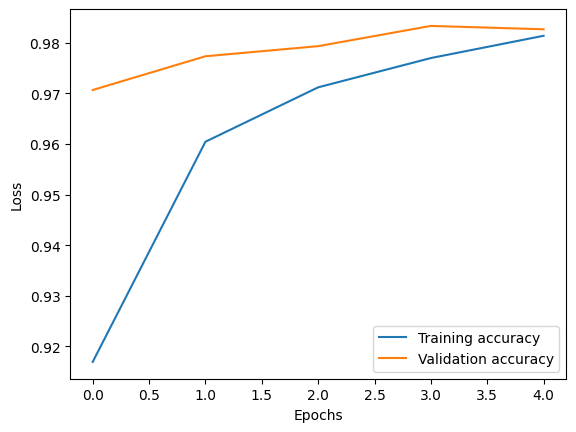

*****************************************************************************
*****************************************************************************
Epoch 1/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8682 - loss: 0.4641 - val_accuracy: 0.9683 - val_loss: 0.1176
Epoch 2/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9590 - loss: 0.1386 - val_accuracy: 0.9780 - val_loss: 0.0837
Epoch 3/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9701 - loss: 0.0983 - val_accuracy: 0.9807 - val_loss: 0.0733
Epoch 4/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9781 - loss: 0.0722 - val_accuracy: 0.9817 - val_loss: 0.0725
Epoch 5/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9818 - loss: 0.0584 - val_accuracy: 0.9817 - val_loss: 0.0730
Epoch 6/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0482 - val_accuracy: 0.9833 - val_loss: 0.0703
Epoch 7/10
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy

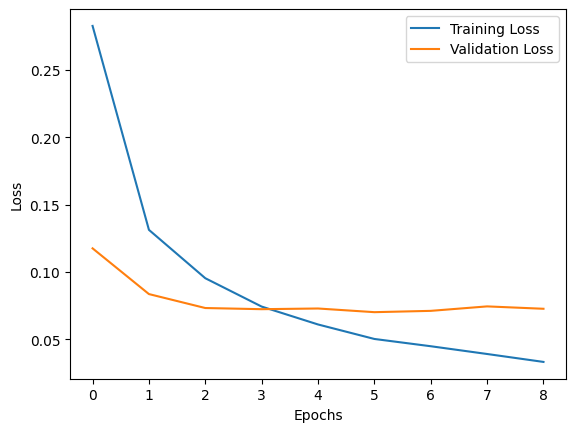

*****************************************************************************


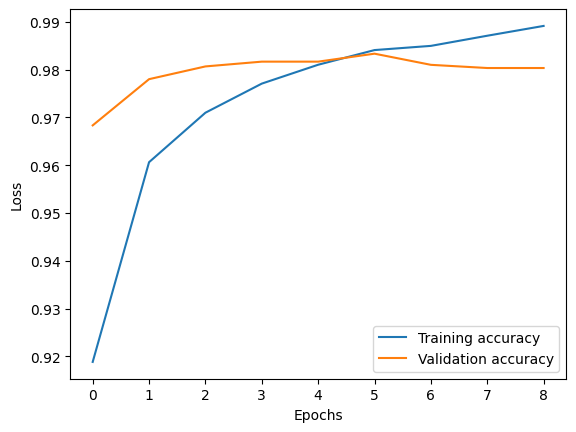

*****************************************************************************
*****************************************************************************
Epoch 1/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8688 - loss: 0.4538 - val_accuracy: 0.9720 - val_loss: 0.1121
Epoch 2/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9587 - loss: 0.1385 - val_accuracy: 0.9797 - val_loss: 0.0819
Epoch 3/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9727 - loss: 0.0935 - val_accuracy: 0.9777 - val_loss: 0.0727
Epoch 4/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9780 - loss: 0.0715 - val_accuracy: 0.9787 - val_loss: 0.0736
Epoch 5/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0561 - val_accuracy: 0.9800 - val_loss: 0.0747
Epoch 6/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9839 - loss: 0.0502 - val_accuracy: 0.9833 - val_loss: 0.0675
Epoch 7/20
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy

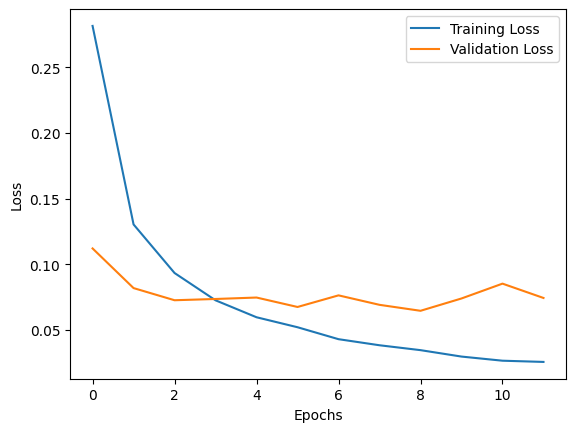

*****************************************************************************


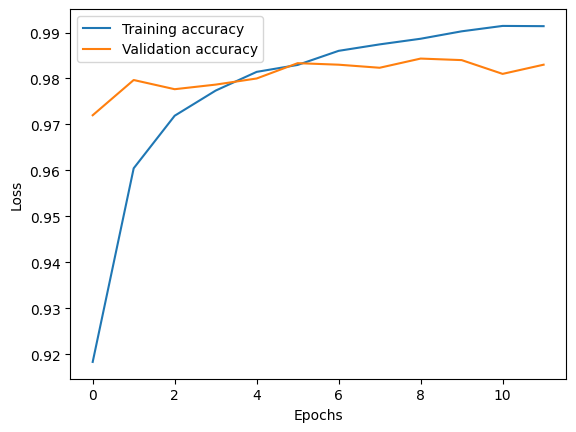

*****************************************************************************
*****************************************************************************


In [ ]:
# Task 3

for epoch in [5,10,20]:
  model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),   # prevent overfitting
    keras.layers.Dense(10, activation="softmax")
  ])

  model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

  callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True) ]


  history = model.fit(
      x_tr, y_tr,
      epochs=epoch,
      batch_size=32,
      validation_data=(x_val, y_val),
      callbacks=callbacks )

  # 6) Plot Training vs Validation Loss
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
  print("*****************************************************************************")
  plt.plot(history.history['accuracy'], label='Training accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
  print("*****************************************************************************")
  print("*****************************************************************************")




Task 3

Identify signs of overfitting.

Overfitting happens when the training loss decrease at the same time of validation loss increases. Vice versa in training accuracy and validation accuracy.

Explain how the optimizer (Adam) influenced the speed and stability of convergence.

Adam calculates a unique, adaptive learning rate for each individual parameter (weight and bias) in the network. This allows it to take larger steps for features that are under-adjusted and smaller steps for sensitive features. This adaptive nature generally results in faster convergence. Adam incorporates an element of momentum by tracking the exponentially decaying averages of both the gradients (like classic momentum) and the squared gradients (like RMSProp). This averaging provides greater stability in the descent towards the global minimum of the loss function.

**TASK 4**

*At which epoch did training stop?*

for 10 epochs, it stopped at 9.
for 20 epochs, it stopped at 12.

*Why does the validation loss control this decision?*

When the training loss continues to decrease but the validation loss begins to increase, it is the obvious sign that the model has started to overfit.
EarlyStopping monitors the validation loss and terminates training before the overfitting becomes extreme.


*What happens if you increase patience (e.g., to 5)?*

If patience were set to 5, the model would only stop if the validation loss failed to improve for five consecutive epochs.

Would a different optimizer (e.g., SGD) change the EarlyStopping pattern?
Yes, an optimizer like SGD (Stochastic Gradient Descent), would significantly change the loss curve and, consequently, the EarlyStopping pattern. When using an optimizer like SGD, you need to increase the patience value to allow the optimizer to smooth out its path to the minimum.

Explain how EarlyStopping acts as an indirect form of regularization.
Regularization is any technique used to reduce overfitting and improve a model's generalization ability. EarlyStopping achieves the same goal, making it an indirect form of regularization.


This full task set is designed to build a deep understanding of neural networks, optimization, and regularization—bridging theory with hands-on experimentation in a structured, progress

---

---

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8704 - loss: 0.4506 - val_accuracy: 0.9698 - val_loss: 0.1151
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9606 - loss: 0.1313 - val_accuracy: 0.9740 - val_loss: 0.0943
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0824 - val_accuracy: 0.9752 - val_loss: 0.0897
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0576 - val_accuracy: 0.9806 - val_loss: 0.0769
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9866 - loss: 0.0436 - val_accuracy: 0.9776 - val_loss: 0.0778
Training with NO DROPOUT


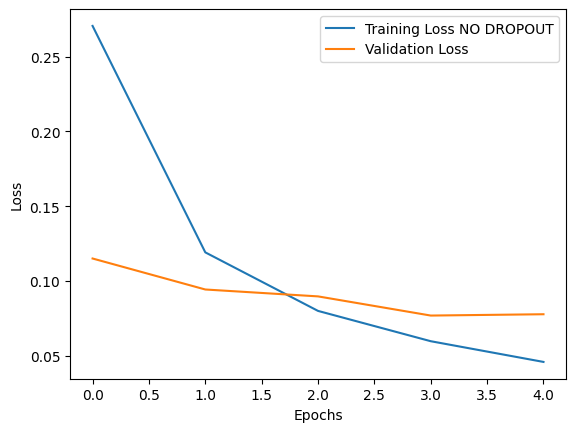

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8613 - loss: 0.4757 - val_accuracy: 0.9686 - val_loss: 0.1193
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9541 - loss: 0.1512 - val_accuracy: 0.9732 - val_loss: 0.0935
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9713 - loss: 0.0974 - val_accuracy: 0.9780 - val_loss: 0.0819
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0745 - val_accuracy: 0.9794 - val_loss: 0.0765
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9819 - loss: 0.0603 - val_accuracy: 0.9802 - val_loss: 0.0738
Training with 0.1 DROPOUT


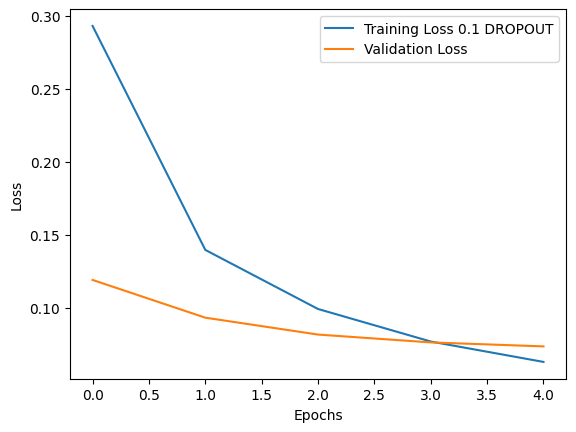

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8428 - loss: 0.5350 - val_accuracy: 0.9642 - val_loss: 0.1265
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9463 - loss: 0.1799 - val_accuracy: 0.9720 - val_loss: 0.0971
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9599 - loss: 0.1340 - val_accuracy: 0.9758 - val_loss: 0.0833
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9666 - loss: 0.1099 - val_accuracy: 0.9790 - val_loss: 0.0758
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9708 - loss: 0.0926 - val_accuracy: 0.9788 - val_loss: 0.0730


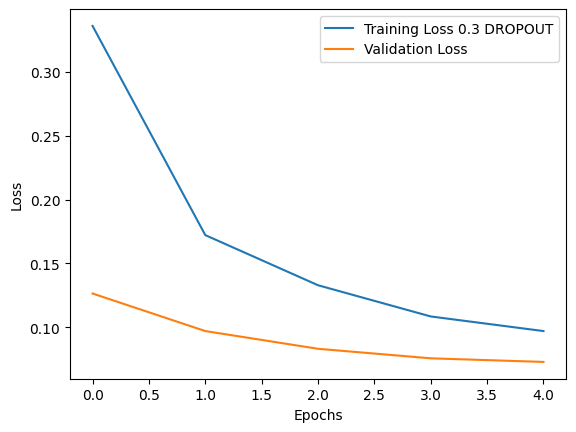

In [ ]:
# Task 5
# No Dropout
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
  ])

model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history = model.fit(
      x_tr, y_tr,
      epochs=5,
      batch_size=32,
      validation_data=(x_val, y_val),)

# Plot Training vs Validation Loss
print("Training with NO DROPOUT")
plt.plot(history.history['loss'], label='Training Loss NO DROPOUT')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 0.1 Dropout ##################

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(10, activation="softmax")
  ])

model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history = model.fit(
      x_tr, y_tr,
      epochs=5,
      batch_size=32,
      validation_data=(x_val, y_val),)

# Plot Training vs Validation Loss
print("Training with 0.1 DROPOUT")
plt.plot(history.history['loss'], label='Training Loss 0.1 DROPOUT')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 0.3 Dropout #####################
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax")
  ])

model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history = model.fit(
      x_tr, y_tr,
      epochs=5,
      batch_size=32,
      validation_data=(x_val, y_val) )

# Plot Training vs Validation Loss
plt.plot(history.history['loss'], label='Training Loss 0.3 DROPOUT')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



**Comparing overfitting levels**

No Dropout (5 epochs): Training loss: 0.0436 - val_loss: 0.0778

0.1 Dropout (5 epochs): Training loss: 0.0603 - val_loss: 0.0738

0.3 Dropout (5 epochs): Training loss: 0.0926 - val_loss: 0.0730

Comment:

No Dropout shows the most overfitting, 0.1 Dropout reduces it, and 0.3 Dropout removes the overfitting signal (validation loss is even lower than training loss) but may be leaning toward underfitting.

A simple overfitting indicator is the generalization gap = val_loss − training_loss

| Dropout | Training loss | Val loss | generalization gap (val−train) |
| ------- | ------------- | -------- | -------------------- |
| 0.0     | 0.0436        | 0.0778   | +0.0342              |
| 0.1     | 0.0603        | 0.0738   | +0.0135              |
| 0.3     | 0.0926        | 0.0730   | −0.0196              |

- Most overfitting: No Dropout, because it achieves the lowest training loss but the highest validation loss and the largest positive gap.

- Better regularization: 0.1 Dropout cuts the gap substantially while also improving validation loss vs no dropout.


**Why val_loss < train_loss**

In Keras/TensorFlow, the Dropout layer only applies when training=True and does nothing during inference (no units are dropped).​
During model.fit, training batches run with dropout active, while validation is evaluated in inference mode, so training loss can be higher than validation loss even when generalization is fine.​


**how Dropout encourages robust representations by preventing neuron co-adaptation**

In standard neural networks trained on limited data, complex patterns emerge where feature detectors rely on specific other neurons being present to correct their mistakes. For example, one neuron might learn to activate only when two other specific neurons are simultaneously active. This creates a brittle system: the learned features work well together on the training set but fail to generalize to test data because those exact neuron combinations won't recur reliably.
The core issue is that these co-adapted features are tuned to work well together on training data but not on the test data because the feature detectors have been tuned to work well together on the training data but not on the test data. Each weight vector that fits the training set perfectly makes different predictions on held-out data, and almost all perform worse on the test set.


## Task 6 — L2 Regularization Experiment

Add L2 regularization:

kernel_regularizer=keras.regularizers.l2(0.001)

Test values:
- 0.0001
- 0.001
- 0.01

Analyze:

 **How L2 reduces weight magnitude:**

L2 regularization adds a penalty term to the loss function that is proportional to the square of the weights.
- The Penalty: During backpropagation, the gradient of the L2 term $w^2$ is $2w$.
- Weight Decay: When the optimizer updates the weights, it doesn't just move in the direction that minimizes the classification error; it also subtracts a portion of the weight itself.
- The Result: Weights are constantly being "pulled" toward zero. Large weights are penalized more heavily than small ones, ensuring no single connection in your Dense(128) layer becomes excessively dominant.

 **Why smaller weights often improve generalization**

as reg_value increases, the gap between training accuracy and validation accuracy generally stabilizes. Smaller weights help because:

- Reduced Sensitivity: If a weight is very large, a tiny change in the input (like random noise in an image) causes a massive change in the output. Small weights make the model "stiff" against noise.

- Simpler Decision Boundaries: High weights allow the model to create highly complex, "wiggly" decision boundaries that fit every outlier in your training set. Smaller weights force the model to learn smoother, more general patterns that represent the dataset as a whole rather than specific training examples.

**How L2 changes the validation loss trend**

Val Loss (End):
- At L2 = 0.0001, val_loss = 0.1168	: Sharpest fit; lowest overall error.
- At L2 = 0.001, val_loss = 0.2403	: Loss is higher, but Val Loss < Training Loss (Very stable).
- At L2 = 0.01, val_loss = 0.6540	: Penalty is too high; model is struggling to learn (Underfitting).

Training model with L2 regularization: 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8742 - loss: 0.4748 - val_accuracy: 0.9676 - val_loss: 0.1473
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9617 - loss: 0.1624 - val_accuracy: 0.9740 - val_loss: 0.1244
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9732 - loss: 0.1288 - val_accuracy: 0.9770 - val_loss: 0.1204
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9778 - loss: 0.1142 - val_accuracy: 0.9780 - val_loss: 0.1190
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.1026 - val_accuracy: 0.9794 - val_loss: 0.1168


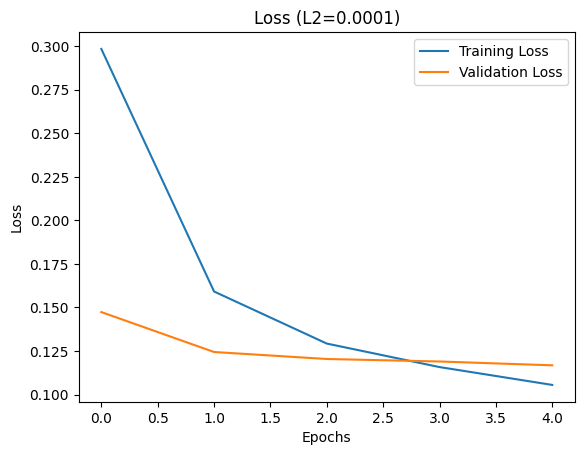

*****************************************************************************
*****************************************************************************
Training model with L2 regularization: 0.001
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8658 - loss: 0.6217 - val_accuracy: 0.9592 - val_loss: 0.2822
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9502 - loss: 0.3026 - val_accuracy: 0.9680 - val_loss: 0.2525
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9595 - loss: 0.2743 - val_accuracy: 0.9640 - val_loss: 0.2631
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9633 - loss: 0.2670 - val_accuracy: 0.9710 - val_loss: 0.2434
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9644 - loss: 0.2660 - val_accuracy: 0.9724 - val_loss: 0.2403


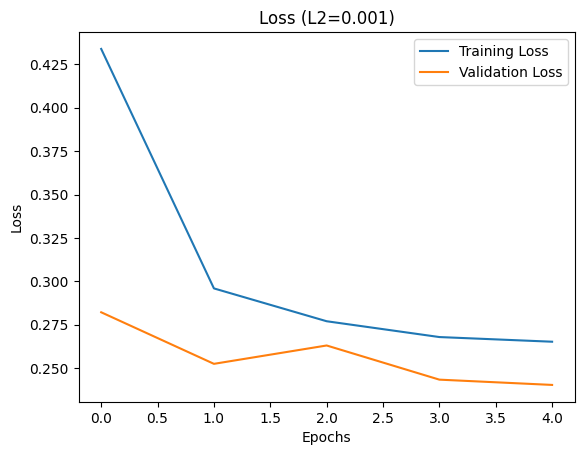

*****************************************************************************
*****************************************************************************
Training model with L2 regularization: 0.01
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8514 - loss: 1.2284 - val_accuracy: 0.9276 - val_loss: 0.6748
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9001 - loss: 0.7479 - val_accuracy: 0.9314 - val_loss: 0.6634
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8985 - loss: 0.7487 - val_accuracy: 0.9246 - val_loss: 0.6634
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.7412 - val_accuracy: 0.9292 - val_loss: 0.6597
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9018 - loss: 0.7338 - val_accuracy: 0.9338 - val_loss: 0.6540


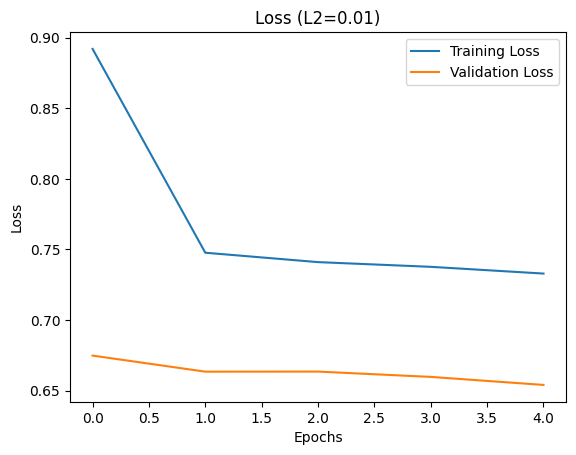

*****************************************************************************
*****************************************************************************


In [ ]:
# Task 6
# adding regularization L2


for reg_value in [0.0001,0.001,0.01]:
  print(f"Training model with L2 regularization: {reg_value}")
  model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(reg_value)),
    keras.layers.Dense(10, activation="softmax", kernel_regularizer=keras.regularizers.l2(reg_value))
  ])

  model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

  callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True) ]


  history = model.fit(
      x_tr, y_tr,
      epochs=5,
      batch_size=32,
      validation_data=(x_val, y_val),
      callbacks=callbacks )

  # 6) Plot Training vs Validation Loss
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'Loss (L2={reg_value})')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
  print("*****************************************************************************")
  print("*****************************************************************************")




### **Task 7 — Optimizer Comparison Challenge**
Train four models using identical architecture but different optimizers:
- SGD (learning_rate=0.01)  
- SGD with Momentum  
- Adam  
- AdamW

**Key Optimizer Differences**
- SGD (Stochastic Gradient Descent): Updates weights using a fixed step. It can be slow and may get stuck in "plateaus" or local minima.

- SGD with Momentum: Adds a "velocity" component. Like a ball rolling down a hill, it gains speed in consistent directions, helping it push through noisy gradients and small local minima.

- Adam (Adaptive Moment Estimation): Calculates individual learning rates for every parameter. It is generally the "go-to" because it handles sparse gradients and noisy data exceptionally well.

- AdamW: Fixes a specific mathematical flaw in how Adam handles L2 regularization (weight decay). In standard Adam, the L2 penalty gets blurred by the adaptive learning rate; AdamW applies the decay directly to the weights, often leading to better generalization.

**For each optimizer**:
1. Plot loss and accuracy curves.  
2. Compare convergence speed and stability.

**Convergence Speed:**

- Adam/AdamW (Fastest): These reached $>91\%$ accuracy in the very first epoch. By epoch 2, they were already at ~95% validation accuracy.
- SGD with Momentum (Fast): Started strong at 90% and caught up to Adam quickly, eventually achieving the highest validation accuracy (97.7%).
- SGD (Slowest): Started at only 81% and required all 8 epochs just to reach the level Adam hit in epoch 2.

**Stability:**
- SGD & SGD Momentum: Showed very stable, steadily decreasing loss. SGD Momentum is particularly impressive here; it didn't suffer from the slight validation loss fluctuations seen in Adam.
- Adam/AdamW: Notice that Adam's validation loss actually increased slightly between Epoch 3 ($0.240$) and Epoch 4 ($0.250$). This "jitter" or instability is common with Adam as it aggressively adjusts learning rates for every parameter.

3. Discuss how each optimizer navigates the loss landscape differently.

The "loss landscape" is a 3D map of all possible weight values and their resulting error.

- SGD: Navigates like a person taking cautious, equal-sized steps. On flat surfaces (plateaus), it barely moves. In steep ravines, it might oscillate slowly.

- SGD with Momentum: Navigates like a heavy ball. It accumulates "velocity" from previous steps. This allows it to roll straight through small local pits and cross flat plateaus much faster than basic SGD.

- Adam: Navigates like a scout with a different speed for every coordinate. It looks at the history of gradients (moments). If a certain weight needs to change a lot, Adam gives it a larger individual learning rate; if a weight is already vibrating too much, Adam slows it down.


4. Explain why Adam often outperforms classical optimizers.

Adam and AdamW reached high performance much earlier than basic SGD. Here is why:

- Adaptive Learning Rates: Basic SGD uses one learning_rate for every single weight in your model. In a Dense layer of 128 neurons, some weights might need to change quickly while others need fine-tuning. Adam handles this automatically.

- Bias Correction: Adam includes a mathematical "warm-up" (bias correction) that prevents the initial steps from being too erratic, allowing it to start training aggressively from Epoch 1.

- Handling Sparse Data: If some pixels in your input images are usually zero (like the corners of the MNIST digits), Adam scales the updates for those specific features so they still contribute to learning, whereas SGD might ignore them.



--- Training with Optimizer: SGD ---
Finished SGD. Final Val Accuracy: 0.9580

--- Training with Optimizer: SGD_Momentum ---
Finished SGD_Momentum. Final Val Accuracy: 0.9772

--- Training with Optimizer: Adam ---
Finished Adam. Final Val Accuracy: 0.9700

--- Training with Optimizer: AdamW ---
Finished AdamW. Final Val Accuracy: 0.9748


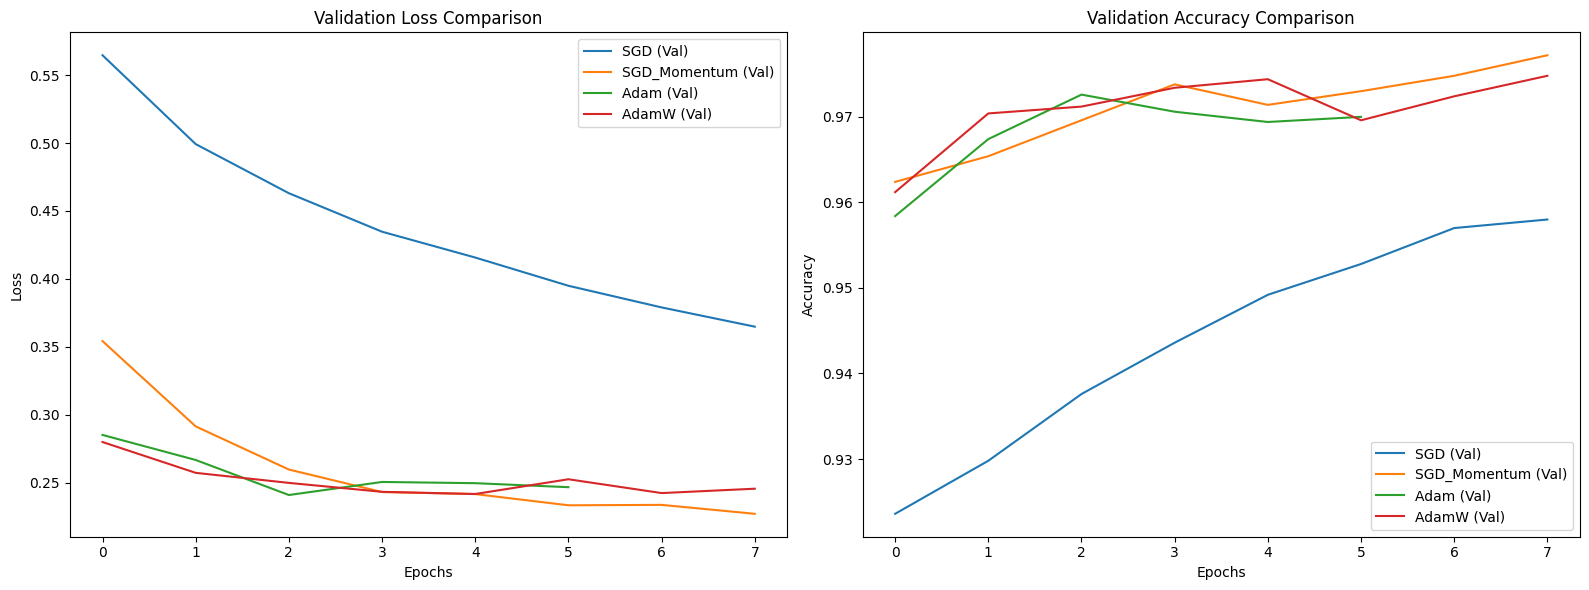

In [ ]:
# Define optimizers to test
optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "SGD_Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adam": keras.optimizers.Adam(learning_rate=0.001),
    "AdamW": keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)
}

# Dictionary to store history for comparison
all_histories = {}

for name, opt in optimizers.items():
    print(f"\n--- Training with Optimizer: {name} ---")

    # Identical Architecture from previous step
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu",
                           kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(10, activation="softmax",
                           kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

    history = model.fit(
        x_tr, y_tr,
        epochs=8, # Increased epochs to see optimizer convergence patterns
        batch_size=32,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=0 # Set to 0 to keep output clean for 4 models
    )

    all_histories[name] = history.history
    print(f"Finished {name}. Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# --- Plotting Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in all_histories.items():
    # Loss Curves
    ax1.plot(hist['val_loss'], label=f'{name} (Val)')
    # Accuracy Curves
    ax2.plot(hist['val_accuracy'], label=f'{name} (Val)')

ax1.set_title('Validation Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## Task 8 — Batch Size & Gradient Noise Experiment

Train the model with batch sizes:
8 , 32 , 128

Discuss:

**Why smaller batches introduce gradient noise.**

Batch 8: the loss curve "jitter" or bounce up and down more. This is because the model is making drastic weight updates based on very small groups of images (high noise).

Batch 128: The curve looks much smoother. The gradients are more stable because they are averaged over many images.

**When this noise is beneficial (escaping local minima).**
The loss landscape of a neural network isn't a smooth bowl; it's full of jagged peaks and shallow pits (local minima).

Large Batches: These are very precise. They lead the model straight into the nearest pit. If that pit is a "local minimum" (a sub-optimal solution), the model gets stuck there.

Small Batches (Noise): Because the steps are noisy, the model "jitters." This jittering acts like shaking a tray with a marble on it. The marble might fall into a small, shallow hole, but the shaking (noise) pops it back out, allowing it to continue searching until it finds a deeper, broader, and more stable "Global Minimum."

How Noise Helps: Noise makes it nearly impossible for a model to stay in a "Sharp" minimum. The fluctuations are too violent for the model to settle in a narrow hole. It can only settle down in a wide, flat area where the noise doesn't push it out easily.


**Why larger batches may converge faster but generalize worse.**

Larger batches converge faster because they allow the hardware to process more data in parallel and provide a stable, accurate gradient that leads the model directly toward a minimum in fewer steps. However, they often generalize worse because this lack of "gradient noise" prevents the model from escaping sharp, narrow local minima that are highly specific to the training data. Without the stochastic "jitter" found in smaller batches, the model fails to explore the loss landscape effectively and misses the broader, flatter minima that typically lead to better performance on unseen data.

**How batch size affects the smoothness of loss curves.**

Batch size determines the smoothness of the loss curve by controlling the amount of "gradient noise" during training. Small batches calculate updates from only a few samples, causing outliers to pull the weights in different directions and resulting in a jagged curve. Conversely, large batches average the gradient over many samples, canceling out individual noise to provide a stable, consistent direction that produces a clean, smooth decline. While large batches look more stable, the "noise" in the jagged curves of small batches often acts as a beneficial force, helping the model avoid sub-optimal solutions.



--- Training with Batch Size: 8 ---

--- Training with Batch Size: 32 ---

--- Training with Batch Size: 128 ---


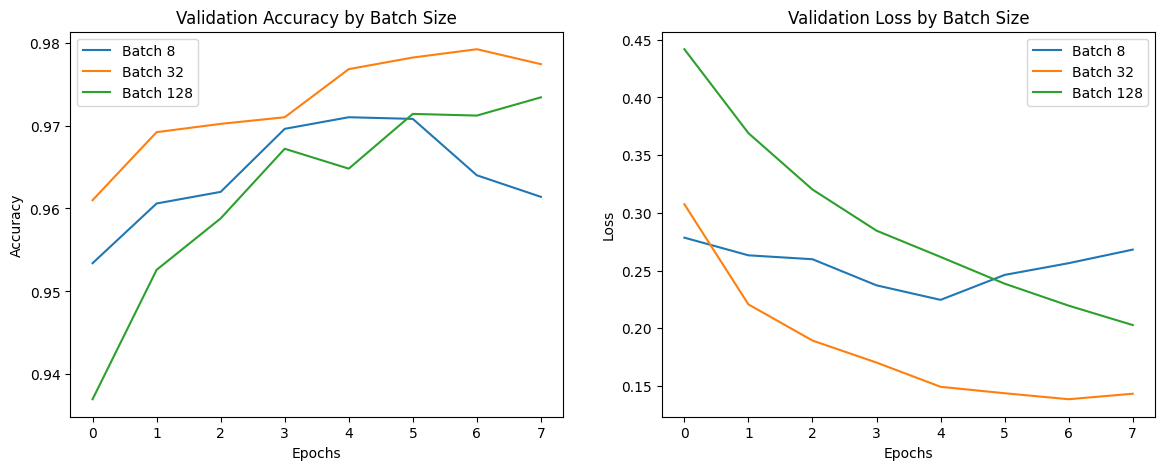

In [ ]:
# Using the best optimizer from our previous test (SGD with Momentum)
batch_sizes = [8, 32, 128]
batch_histories = {}

for b_size in batch_sizes:
    print(f"\n--- Training with Batch Size: {b_size} ---")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu",
                           kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
    history = model.fit(
        x_tr, y_tr,
        epochs=8,
        batch_size=b_size,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=0
    )

    batch_histories[b_size] = history.history

# --- Visualization ---
plt.figure(figsize=(14, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
for b_size, hist in batch_histories.items():
    plt.plot(hist['val_accuracy'], label=f'Batch {b_size}')
plt.title('Validation Accuracy by Batch Size')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Validation Loss
plt.subplot(1, 2, 2)
for b_size, hist in batch_histories.items():
    plt.plot(hist['val_loss'], label=f'Batch {b_size}')
plt.title('Validation Loss by Batch Size')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

###


Training with: tanh


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8687 - loss: 0.4564 - val_accuracy: 0.9594 - val_loss: 0.1474
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9519 - loss: 0.1641 - val_accuracy: 0.9700 - val_loss: 0.1053
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9693 - loss: 0.1042 - val_accuracy: 0.9760 - val_loss: 0.0903
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9774 - loss: 0.0761 - val_accuracy: 0.9744 - val_loss: 0.0834
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0547 - val_accuracy: 0.9806 - val_loss: 0.0741


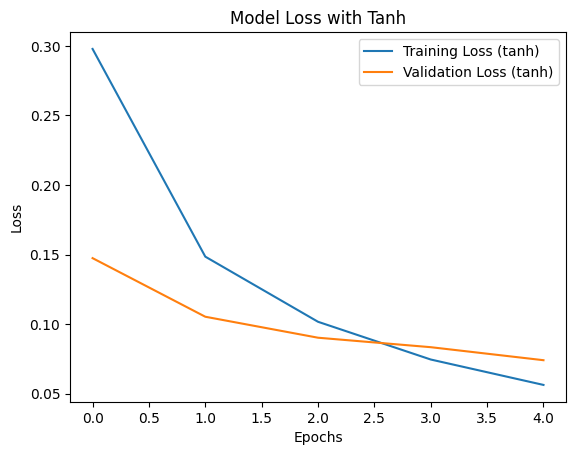


Training with: softsign
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8646 - loss: 0.4920 - val_accuracy: 0.9576 - val_loss: 0.1563
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9478 - loss: 0.1769 - val_accuracy: 0.9682 - val_loss: 0.1149
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9652 - loss: 0.1197 - val_accuracy: 0.9694 - val_loss: 0.1052
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9734 - loss: 0.0944 - val_accuracy: 0.9710 - val_loss: 0.0978
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0707 - val_accuracy: 0.9746 - val_loss: 0.0851


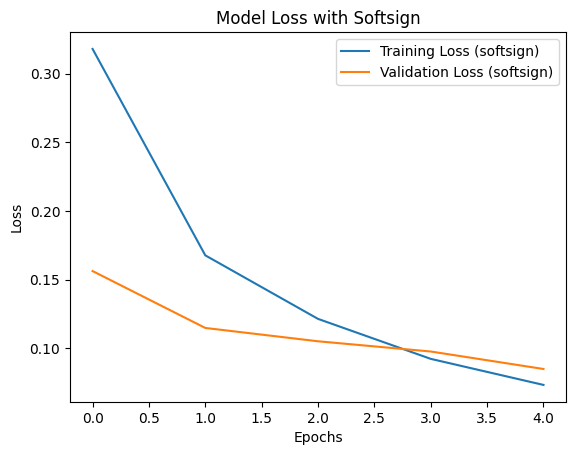


Training with: gelu
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8700 - loss: 0.4519 - val_accuracy: 0.9680 - val_loss: 0.1162
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9644 - loss: 0.1257 - val_accuracy: 0.9744 - val_loss: 0.0965
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9755 - loss: 0.0822 - val_accuracy: 0.9766 - val_loss: 0.0818
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9840 - loss: 0.0549 - val_accuracy: 0.9766 - val_loss: 0.0859
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9884 - loss: 0.0399 - val_accuracy: 0.9766 - val_loss: 0.0813


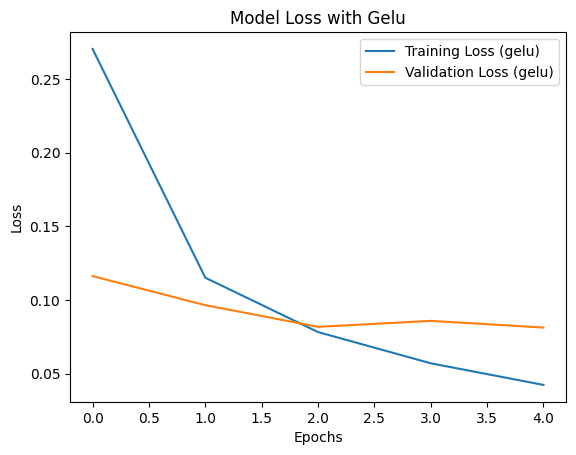

In [7]:
# Task 9 : try Modify the model by replacing ReLU with: Tanh, Softsign ,GELU

activations = ['tanh', 'softsign', 'gelu']

for act in activations:
    print(f"\nTraining with: {act}")

    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        # Replace "relu" with your chosen activation here:
        keras.layers.Dense(128, activation=act),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
          x_tr, y_tr,
          epochs=5,
          batch_size=32,
          validation_data=(x_val, y_val),
          verbose=1)

    # Plotting results
    plt.plot(history.history['loss'], label=f'Training Loss ({act})')
    plt.plot(history.history['val_loss'], label=f'Validation Loss ({act})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Model Loss with {act.capitalize()}')
    plt.legend()
    plt.show()

1. Gradient Flow and the Vanishing Gradient Risk

Gradient flow refers to how well the "error signal" travels back through the layers during backpropagation.
Tanh and Softsign (High Risk): Both are saturating functions. As inputs get very large (positive or negative), the slope (derivative) of the curve becomes nearly flat (zero).Vanishing Gradient: In deep networks, multiplying many small derivatives (near 0) together makes the gradient vanish, meaning the early layers stop learning. Tanh is more prone to this because it saturates faster than Softsign.
GELU and ReLU (Low Risk): These do not saturate for positive values. The gradient remains $1$ (for ReLU) or near $1$ (for GELU) as $x$ increases, allowing the signal to flow freely across many layers.

2. Why GELU performs well in Transformers

GELU (Gaussian Error Linear Unit) is essentially a "smarter" ReLU. While ReLU strictly cuts off all negative values at zero, GELU weights inputs by their magnitude based on a probability distribution (the Gaussian CDF).
Smoothness: GELU is differentiable at all points, unlike ReLU which has a sharp "kink" at zero. This smoothness helps optimizers like Adam find better minima in complex Transformer architectures.
Stochasticity: It acts as a bridge between a regular activation and stochastic dropout. By allowing a small amount of negative information to pass through, it helps preserve more complex patterns in large datasets.

3. Why ReLU remains the "Standard" for MLP and CNNs

Despite newer functions like GELU, ReLU ($f(x) = \max(0, x)$) is still the go-to for most standard models for several practical reasons:Computational Efficiency: ReLU is incredibly "cheap" to calculate—it's just a simple threshold at zero. Tanh, Softsign, and GELU involve exponents or divisions, which are more taxing during millions of training iterations.Sparsity: ReLU produces "true zeros." This makes the network sparse (not every neuron is active), which can improve generalization and act as a natural form of regularization.Convergence Speed: In most standard CNNs or MLPs, ReLU converges much faster than saturating functions (like Tanh) because it doesn't suffer from the "flat slope" problem on the positive side.

# task10

In [8]:
# Task 10
w, b = model.layers[1].get_weights()
print(w.shape)

(784, 128)


1. Why is the number of parameters so large?

The output (784, 128) represents the weight matrix $W$ connecting the input layer to the first hidden layer.Dense Connectivity: In a Fully Connected (Dense) layer, every single input pixel (28x28 = 784) must have a unique weight connecting it to every single neuron in the next layer (128).The Math: $784 \times 128 = 100,352$ weights.

If you add the 128 bias terms, you have 100,480 trainable parameters in just the first layer.Scale: Even a small image like MNIST generates over 100k variables that the optimizer must tune. In higher-resolution images (e.g., 224x224), this number would explode into the millions, which is why we usually switch to CNNs for larger tasks.

2. High Model Capacity vs. Overfitting

Model capacity is like the "memory" of your network.The Risk: When capacity is high (too many neurons/layers), the model doesn't just learn the general rules of a digit (like "a circle is a zero"); it begins to memorize the noise or specific quirks of the training images.The Result: You see a very low Training Loss but a high Validation Loss. The model becomes a "lookup table" rather than a generalized processor.

3. Mitigating Overfitting:

- Dropout: Randomly "turns off" neurons during each training step.
- L2 Regularization:	Adds a penalty to the loss function based on the size of the weights (squared).
- Early Stopping:	Monitored the validation loss and kills the training before the model starts memorizing noise.